In [4]:
%reload_ext autoreload
%autoreload 2

import sys
import os

cwd = os.getcwd()
parent_dir = os.path.abspath(os.path.join(cwd, '..'))
sys.path.append(parent_dir)

import c2qa
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumRegister, ClassicalRegister
from qiskit.circuit.library import RGate
from qiskit.converters import circuit_to_gate
from qutip import *
from qiskit.circuit import Parameter
from qiskit.circuit.library import UnitaryGate
from custom_gates import state_generation
from qiskit.visualization import plot_histogram

In [5]:
cutoff = 2**6
alpha = 4.0/np.sqrt(2)

cdReal = state_generation.CD_real(cutoff,-alpha)
cdImaginary = state_generation.CD_imaginary(cutoff,-alpha)

In [6]:
Nmodes=1
Nqubits = 1 

qmr = c2qa.QumodeRegister(num_qumodes=1, num_qubits_per_qumode=int(np.ceil(np.log2(cutoff))))

qbr = QuantumRegister(Nqubits)
cbr = ClassicalRegister(Nqubits)

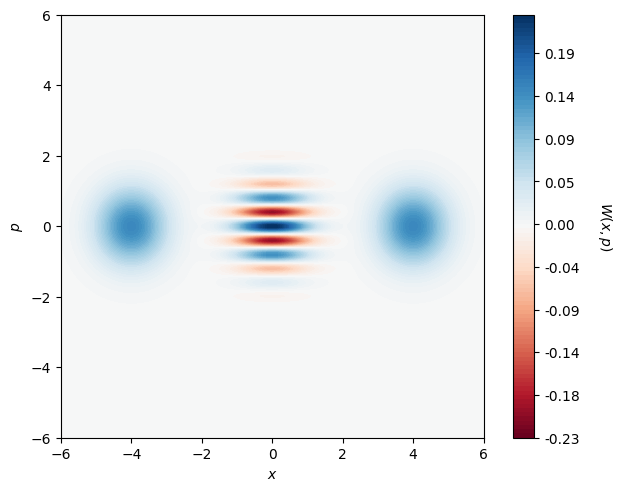

In [7]:
CD_real_gate = UnitaryGate(cdReal.full(), label='CD_real')
CD_imag_gate = UnitaryGate(cdImaginary.full(), label='CD_imaginary')

circuit = c2qa.CVCircuit(qmr, qbr,cbr)
circuit.initialize(1,qbr)
circuit.append(CD_real_gate, qmr[:] + qbr[:])
circuit.append(CD_imag_gate, qmr[:] + qbr[:])


stateop, result, _ = c2qa.util.simulate(circuit,shots = 1024)

fig = c2qa.wigner.plot_wigner(circuit, stateop)

In [8]:
bq_state = c2qa.wigner.trace_out_qubits(circuit, stateop)

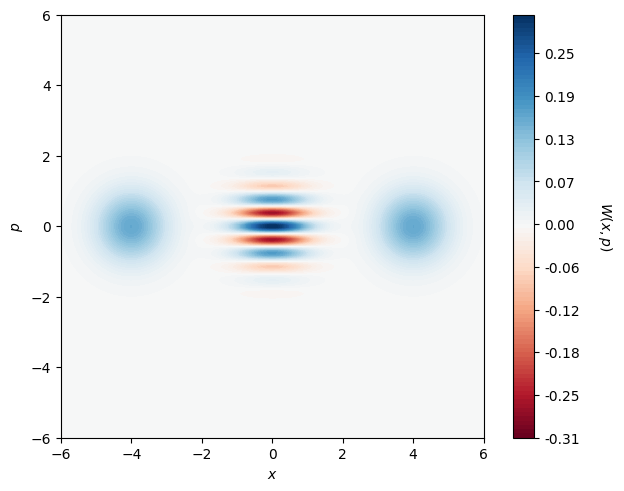

In [9]:
osc_init = coherent(cutoff,-4.0/np.sqrt(2)) + coherent(cutoff,4.0/np.sqrt(2))
qmr = c2qa.QumodeRegister(1, num_qubits_per_qumode = 6)
circuit = c2qa.CVCircuit(qmr)
circuit.cv_initialize(osc_init.full(), qmr[0])

state_test, result, _ = c2qa.util.simulate(circuit,shots = 1024)
c2qa.wigner.plot_wigner(circuit, state_test)

In [10]:
reference_state = c2qa.wigner.trace_out_qubits(circuit, state_test)

In [11]:
from qiskit.quantum_info import state_fidelity
print("Fidelity =", state_fidelity(bq_state,reference_state))

Fidelity = 0.8638906096310333
